# Numerical Methods Project: Solving Boundary Value Problems
Daniel Li, Yixuan Li, Eric Chen

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.contrib.concurrent import thread_map

f32 = np.float32

In [4]:
# constant parameters
L: f32 = 10   # rod length (m)
k: f32 = 0.01 # convection coeff (m^-2)
T_a: f32 = 20 # ambient temp (deg C)

# dirichlet boundary conditions (deg C)
T_0 = 40
T_L = 200

## Analytical Solution
$$T(x) = T_a + C_1 e^{\sqrt{k}x} + C_2 e^{-\sqrt{k}x}, \quad T(0) = 40 \degree \text C, \quad T(10) = 200 \degree \text C$$
Plug in at $x = 0, 10$, with $T_a = 20 \degree \text C, \sqrt{k} = 0.1$, to get the following system
$$40 = 20 + C_1 + C_2$$$$200 = 20 + C_1 e + C_2 \frac1e$$
Which we solve to get
$$C_1 = \frac{180e - 20}{e^2 - 1}, \quad C_2 = \frac{20e^2 - 180e}{e^2 - 1}$$

In [5]:
# analytical solution
e: f32 = np.exp(1)
C_1: f32 = (180*e - 20)/(e*e - 1)
C_2: f32 = (20*e*e - 180*e)/(e*e - 1)
a_sol = lambda x: T_a + C_1 * np.exp(np.sqrt(k)*x) + C_2 * np.exp(-np.sqrt(k)*x)

In [6]:
def solveBVP_2O(N: int) -> f32:
    h = L / N

    main_diag = np.ones(N - 1, dtype=f32) * (2 + k * h*h)
    side_diag = np.ones(N - 2, dtype=f32)
    A = np.diag(side_diag, k=1) + np.diag(side_diag, k=-1) - np.diag(main_diag)

    B = np.ones(N - 1, dtype=f32) * (-k * h*h * T_a)
    B[0] -= T_0
    B[-1] -= T_L

    T_num = np.linalg.solve(A, B)
    T_acc = a_sol(np.linspace(0, L, N, endpoint=False)[1:]).astype(f32)

    E_avg = np.abs(T_acc - T_num).sum()
    
    return E_avg

  0%|          | 0/95 [00:00<?, ?it/s]

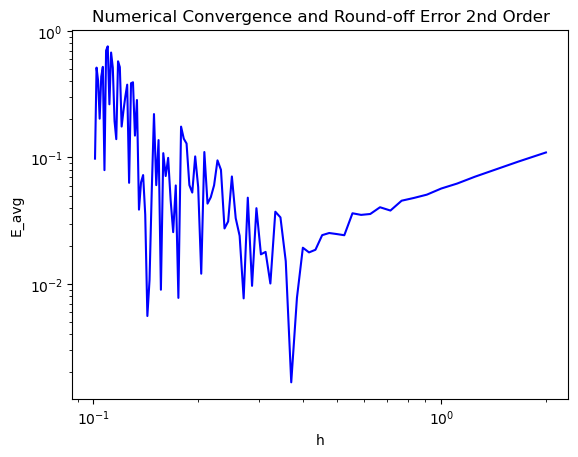

In [55]:
def plotBVP_2O(minN: int=5, maxN: int=100):
    # project spec wanted maxN = 10_000_000 for h = 10^(-6)
    # unfortunately that would mean having a 400 terabyte matrix
    # and i dont have a supercomputer
    # maxN = 100 is sufficient to show where round-off error begins to dominate
    
    N = range(minN, maxN)
    h = [L/n for n in N]
    E_avg = thread_map(solveBVP_2O, N, max_workers=8)

    plt.loglog(h, E_avg, c="blue", label="2nd order")
    plt.xlabel("h")
    plt.ylabel("E_avg")
    plt.title("Numerical Convergence and Round-off Error 2nd Order")
plotBVP_2O()

## 4th Order Scheme
Using 4th-order Central Difference:
$$T_i'' \approx \frac{-T_{i+2} + 16T_{i+1} - 30T_i + 16T_{i-1} - T_{i-2}}{12h^2}$$
Plugging it into the ODE we get:
$$\frac{-T_{i+2} + 16T_{i+1} - 30T_i + 16T_{i-1} - T_{i-2}}{12h^2} - k(T_i - T_a) = 0$$
Which simplifies to
$$-T_{i+2} + 16T_{i+1} - (30 + 12kh^2)T_i + 16T_{i-1} - T_{i-2} = -12kh^2 T_a$$
Thus our system of equations is:
$$\begin{aligned}
T_0  - (2 + kh^2)T_1 + T_2 &= -kh^2T_a \\
-T_0 + 16T_1 - (30 + 12kh^2)T_2 + 16T_3 - T_4 &= -12kh^2T_a \\
-T_1 + 16T_2 - (30 + 12kh^2)T_3 + 16T_4 - T_5 &= -12kh^2T_a \\
\vdots \quad \quad &= \quad \vdots \\
-T_{N-4} + 16T_{N-3} - (30 + 12kh^2)T_{N-2} + 16T_{N-1} - T_N &= -12kh^2T_a \\
T_{N-2}  - (2 + kh^2)T_{N-1} + T_N &= -kh^2T_a
\end{aligned}$$
And in pentadiagonal matrix form that is:
$$\begin{bmatrix}
-(2 + kh^2) & 1 & 0 & 0 & \cdots & \cdots & \cdots & \cdots & \cdots & 0 \\
16 & -(30 + 12kh^2) & 16 & -1 & 0 & \cdots & \cdots & \cdots & \cdots & 0 \\
-1 & 16 & (-30 + 12kh^2) & 16 & -1 & 0 & \cdots & \cdots & \cdots & 0 \\
0 & -1 & 16 & (-30 + 12kh^2) & 16 & -1 & 0 & \cdots & \cdots & 0 \\
\vdots & \ddots & \ddots & \ddots & \ddots & \ddots & \ddots & \ddots & \ddots & \vdots \\
\vdots & \ddots & \ddots & \ddots & \ddots & \ddots & \ddots & \ddots & \ddots & \vdots \\
\vdots & \ddots & \ddots & \ddots & \ddots & \ddots & \ddots & \ddots & \ddots & \vdots \\
0 & \cdots & \cdots & \cdots & 0 & -1 & 16 & (-30 + 12kh^2) & 16 & -1 \\
0 & \cdots & \cdots & \cdots & \cdots & 0 & -1 & 16 & (-30 + 12kh^2) & 16 \\
0 & \cdots & \cdots & \cdots & \cdots & \cdots & \cdots & 0 & 1 & -(2 + kh^2)
\end{bmatrix} \begin{bmatrix}
T_1 \\ T_2 \\ T_3 \\ T_4 \\ \vdots \\ \vdots \\ \vdots \\ T_{N-3} \\ T_{N_2} \\ T_{N-1}
\end{bmatrix} = \begin{bmatrix}
-kh^2T_a - T_0 \\ -12kh^2T_a + T_0 \\ -12kh^2T_a \\ -12kh^2T_a \\ \vdots \\ \vdots \\ \vdots \\ -12kh^2T_a \\ -12kh^2T_a + T_N \\ -kh^2T_a - T_N
\end{bmatrix}$$

In [48]:
def solveBVP_4O(N: int):
    h = L / N

    diag0 = np.ones(N - 1, dtype=f32) * (30 + 12 * k * h*h)
    diag1 = np.ones(N - 2, dtype=f32) * 16
    diag2 = np.ones(N - 3, dtype=f32)
    A = -np.diag(diag2, k=-2) + np.diag(diag1, k=-1) - np.diag(diag0, k=0) + np.diag(diag1, k=1) - np.diag(diag2, k=2)
    A[0][0] = -(2 + k * h*h)
    A[0][1] = 1
    A[0][2] = 0
    A[-1][-1] = -(2 + k * h*h)
    A[-1][-2] = 1
    A[-1][-3] = 0

    B = np.ones(N - 1, dtype=f32) * (-12 * k * h*h * T_a)
    B[0] = -k*h*h*T_a - T_0
    B[1] += T_0
    B[-1] = -k*h*h*T_a - T_L
    B[-2] += T_L

    T_num = np.linalg.solve(A, B)
    T_acc = a_sol(np.linspace(0, L, N, endpoint=False)[1:]).astype(f32)

    E_avg = np.abs(T_acc - T_num).sum()
    
    return E_avg

  0%|          | 0/95 [00:00<?, ?it/s]

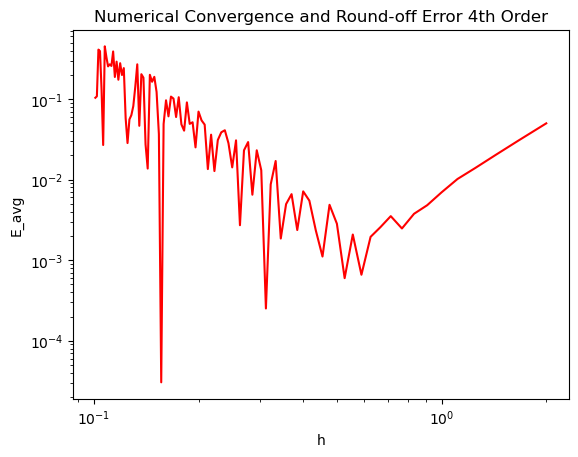

In [57]:
def plotBVP_4O(minN: int=5, maxN: int=100):
    N = range(minN, maxN)
    h = [L/n for n in N]
    E_avg = thread_map(solveBVP_4O, N, max_workers=8)

    plt.loglog(h, E_avg, c="red", label="4th order")
    plt.xlabel("h")
    plt.ylabel("E_avg")
    plt.title("Numerical Convergence and Round-off Error 4th Order")
plotBVP_4O()

## Comparison

  0%|          | 0/95 [00:00<?, ?it/s]

  0%|          | 0/95 [00:00<?, ?it/s]

(0.001, 1)

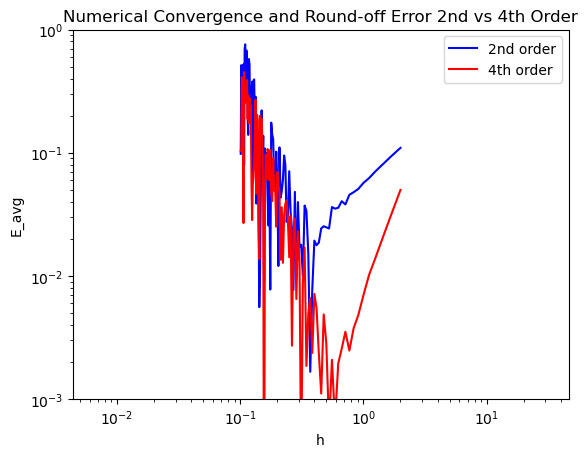

In [92]:
plotBVP_2O()
plotBVP_4O()
#plt.scatter([2, 1, 0.5, 0.1, 0.001], [0.001]*5)
plt.title("Numerical Convergence and Round-off Error 2nd vs 4th Order")
plt.legend()
plt.axis("equal")
plt.ylim(0.001, 1)

# Analysis
The observed slopes in the above graph seem to be roughly 1 for 2nd order and 2 for 4th order. Not sure why it's not 2 and 4.

In [80]:
print("------------------------ Summary Table -------------------------")
print("Step Size (h) [m]:\t2.0\t1.0\t0.5\t0.1\t0.001")
print(f"2nd Order Error [°C]:\t{solveBVP_2O(5):.4f}\t{solveBVP_2O(10):.4f}\t{solveBVP_2O(20):.4f}\t{solveBVP_2O(100):.4f}\t{solveBVP_2O(1000):.4f}")
print(f"4th Order Error [°C]:\t{solveBVP_4O(5):.4f}\t{solveBVP_4O(10):.4f}\t{solveBVP_4O(20):.4f}\t{solveBVP_4O(100):.4f}\t{solveBVP_4O(1000):.4f}")
# i dont think the observed slope column of the table makes sense?

------------------------ Summary Table -------------------------
Step Size (h) [m]:	2.0	1.0	0.5	0.1	0.001
2nd Order Error [°C]:	0.1096	0.0568	0.0248	0.8680	390.9896
4th Order Error [°C]:	0.0499	0.0070	0.0028	0.1954	390.9889
